In [ ]:
#Chanllenge #1, DataFrame Creation

import pandas as pd
data = {
    'Employee_ID': ['E001', 'E002', 'E003', 'E004', 'E005'],
    'Name': ['Abebe', 'Beyene', 'Chala', 'Desta', 'Eden'],
    'Department': ['HR', 'IT', 'Finance', 'IT', 'HR'],
    'Salary': [50000, 75000, 60000, 80000, 55000],
    'Years_Experience': [2, 5, 3, 7, 1]
}
df=pd.DataFrame(data)
df['Bonus']=(df['Salary']*0.1)
print(f"Employees with salary > 60000 :\n{df[df['Salary']>60000]}")
print("*"*65)
print(f"Basic Stastics using describe methed: \n{df.describe()}")
print("*"*65)
print(f"the frist three rows filtered by head:\n{df.head(3)}")
print("*"*65)
print(df)
# print(df.columns)



In [ ]:
#Chanllenge #2, Data Selection and Indexing
import pandas as pd
import numpy as np

# Creating an NBA-like dataset with missing data
data = {
    'Player': ['LeBron James', 'Stephen Curry', 'Giannis A.', 'Luka Doncic', 'Kevin Durant',
               'Joel Embiid', 'Nikola Jokic', 'Jayson Tatum', 'Anthony Davis', 'Devin Booker',
               'Ja Morant', 'Shai G.-A.', 'Jimmy Butler', 'Damian Lillard', 'Kyrie Irving',
               'James Harden', 'Kawhi Leonard', 'Jaylen Brown', 'Donovan Mitchell', 'Anthony Edwards'],
    'Position': ['SF', 'PG', 'PF', 'PG', 'PF', 'C', 'C', 'SF', 'PF', 'SG', 
                 np.nan, 'SG', 'SF', 'PG', 'SG', 'PG', np.nan, 'SG', 'SG', 'SG'],
    'Age': [39, 36, 29, 25, 35, np.nan, 29, 26, 31, 27, 24, 25, np.nan, 33, 32, 34, 34, np.nan, 27, 22],
    'Salary': [47600000, 51900000, np.nan, 40000000, 47600000, 47600000, 47600000, np.nan, 40600000, 36000000,
               34000000, 33300000, 45100000, np.nan, 37000000, 35600000, 45600000, 31800000, np.nan, 13500000],
    'Games_Played': [71, np.nan, 73, 70, 75, 39, np.nan, 74, 76, 68, 9, 75, 60, 73, np.nan, 72, 68, 70, 55, np.nan]
}
df=pd.DataFrame(data)
## Usage of loc, used for only strings
df.index=[f"Row_{i}" for i in range(1,21)]
specific_rows=df.loc[["Row_3","Row_5","Row_12"]]
print(specific_rows)
print("*"*65)
## usage of iloc, used for only integers not for string
subset_iloc=df.iloc[0:5, 2:5]
print(subset_iloc)
print("*"*65)
#cleaning the data
print(df.isna().sum().sum())
#printing only name and salary columns
print(df[['Player','Salary']].head())
print("*"*65)
#pringting ages greater than 25
print(df[df['Age']>25])
print("*"*65)
print(df[(df['Position']=='PG') & (df['Salary']>5000000)])
print("*"*65)
print(df)


In [ ]:
#Challenge 3, Wroking with missing data
import pandas as pd
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David', None,None],
    'Score1': [85, None, 78, 92, 88,None],
    'Score2': [90, 85, None, 87, 76,34],
    'Score3': [78, 82, 85, None, 80,78]
})
print(df)
print(df.isna().sum())
print(df.isna().sum().sum())
score2_mean=df['Score2'].mean()
score1_mean=df['Score1'].mean()
print(score1_mean)
print(score2_mean)
df['Score1']=df['Score1'].fillna(score1_mean)
df['Score2']=df['Score2'].fillna(score2_mean)
# To delete the columns with more than 2 empty cells
empty_cells_greater_two=df.isna().sum()>=2
columns_to_drop=empty_cells_greater_two[empty_cells_greater_two].index
df_cleaned=df.drop(columns=columns_to_drop)
print(f"Cleaned data after filtering the empty cells greater than 2:\n{df_cleaned
}")
print("*"*65)
# to delete the rows with more than 2 empty cellls
row_mask=df.isna().sum(axis=1)>2
df_cleaned=df[~row_mask]
print(df_cleaned)
print("*"*65)
# creating a flag shows the rows with missing data
df['Has_Missing_Data'] = df.isna().any(axis=1).astype(int)
print(df['Has_Missing_Data'])
print("*"*65)
      

In [ ]:
#Challenge 4, Iterating Through DataFram
import pandas as pd

students = {
    'Name': ['Dereje', 'Dagmawit', 'Eyasu', 'Yishak', 'Hanna'],
    'Math': [85, 90, 78, 92, 88],
    'Science': [80, 85, 82, 79, 91],
    'English': [75, 88, 90, 85, 82]
}
df=pd.DataFrame(students)
print("--- Student Averages (Iterations) ---")
## Iterating throgh the rows using the key word iterrows
for index, row in df.iterrows():
    avg=(row['Math']+row['Science'] + row['English'])/3
    # Adding the column Average using iterrows(Iterations)
    # df.loc[index, 'Average']=avg
    print(f"Studnet:{row['Name']}, Average:{avg:.2f}")
#adding the column using verctorization
df['Average']=df[['Math','Science','English']].mean(axis=1)
#Finding students who score greater than 85
print("Students with greater than 85 average:")
for index, row in df.iterrows():
    if row['Average']>85:
        print(f"Student:{row['Name']} with {row['Average']}")
## using tuples to map name and score
name_to_total={}
print("mapping the name and score of students using the itertuple, fast")
for row in df.itertuples():
    total_score=row.Math + row.Science + row.English
    name_to_total[row.Name]=total_score
print("\n ---- Name to Total Score Dictionary -----")
print(name_to_total)
## Iterating throgh columns
for col_name, col_data in df.items():
    if col_name!='Name':
        print(f"Colunm`{col_name}` Mean:{col_data.mean():.2f}")
print(df)

In [ ]:
# Challenge 5, Data Cleaning and wragling
import pandas as pd
df = pd.DataFrame({
    'ID': [1, 2, 3, 4, 5, 6, 7, 8],
    'Product': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'Price': [100, None, 150, 200, None, 175, None, 225],
    'Quantity': [10, 20, None, 30, 25, 35, 40, None],
    'age': [None, None, None, None, None, None, None, None],
    'Region': ['North', 'South', None, 'East', 'West', 'North', None, 'South']
})
numeric_cols=df.select_dtypes(include='number').columns
text_cols=df.select_dtypes(include="object").columns
print(text_cols)
df_cleaned=df.dropna(subset=numeric_cols, how='all')
print(df_cleaned)
most_frequent_region=df['Region'].mode()[0]
df['Region']=df['Region'].fillna(most_frequent_region)
##Seting flag columns
has_missing_values=df.isna().any(axis=0).astype(int)
print(has_missing_values)
# print(df)

In [1]:
#Challenge 6, removing Duplcates
import pandas as pd
df = pd.DataFrame({
    'Order_ID': [101, 102, 103, 104, 101, 105, 102, 106],
    'Customer': ['A', 'B', 'C', 'D', 'A', 'E', 'B', 'F'],
    'Product': ['X', 'Y', 'Z', 'X', 'X', 'Y', 'Y', 'Z'],
    'Date': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
             '2023-01-01', '2023-01-05', '2023-01-02', '2023-01-06'],
    'Amount': [100, 200, 150, 300, 100, 250, 200, 175]
})
print(df)
print(df.duplicated().astype(int))
duplicates=df[df.duplicated(subset=["Order_ID"], keep=False)]
print(f"all dupliated data: \n{duplicates}")
print(df.drop_duplicates())
df_first_order=df.drop_duplicates(subset=["Order_ID"], keep="first")
df_last_order=df.drop_duplicates(subset=["Customer","Product"], keep="last")


print(df_last_order)
print(df_first_order)


   Order_ID Customer Product        Date  Amount
0       101        A       X  2023-01-01     100
1       102        B       Y  2023-01-02     200
2       103        C       Z  2023-01-03     150
3       104        D       X  2023-01-04     300
4       101        A       X  2023-01-01     100
5       105        E       Y  2023-01-05     250
6       102        B       Y  2023-01-02     200
7       106        F       Z  2023-01-06     175
0    0
1    0
2    0
3    0
4    1
5    0
6    1
7    0
dtype: int64
all dupliated data: 
   Order_ID Customer Product        Date  Amount
0       101        A       X  2023-01-01     100
1       102        B       Y  2023-01-02     200
4       101        A       X  2023-01-01     100
6       102        B       Y  2023-01-02     200
   Order_ID Customer Product        Date  Amount
0       101        A       X  2023-01-01     100
1       102        B       Y  2023-01-02     200
2       103        C       Z  2023-01-03     150
3       104        D       X

51750.0
61250.0
9500.0
37500.0
75500.0
IQR outliers:
    Employee Department  Salary
19        20    Finance  195000


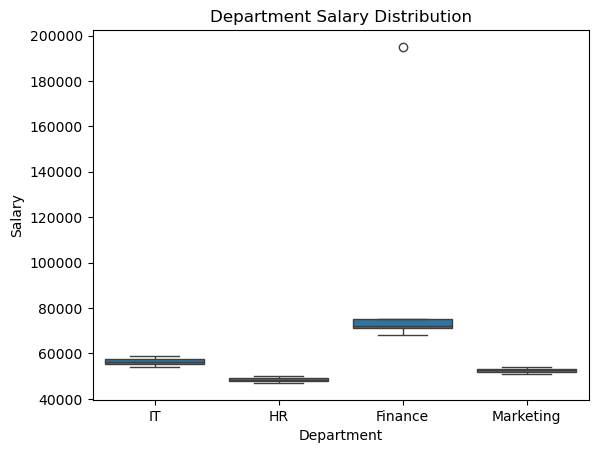

In [20]:
#Challenge 6, Handling outliers
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
salaries = {
    'Employee': list(range(1, 21)),
    'Department': ['IT', 'HR', 'Finance', 'IT', 'Marketing', 'IT', 'HR', 
                   'Finance', 'Marketing', 'IT', 'Finance', 'HR', 'IT',
                   'Marketing', 'Finance', 'IT', 'HR', 'Marketing', 'IT', 'Finance'],
    'Salary': [55000, 48000, 72000, 58000, 51000, 56000, 49000,
               75000, 53000, 57000, 68000, 47000, 59000,
               52000, 71000, 54000, 50000, 54000, 56000, 195000]
}
df=pd.DataFrame(salaries)
Q1=df['Salary'].quantile(0.25)
Q3=df['Salary'].quantile(0.75)
print(Q1)
print(Q3)
IQR=Q3-Q1
print(IQR)
lower_limit=Q1-1.5*IQR
upper_limit=Q2+1.5*IQR
print(lower_limit)
print(upper_limit)
iqr_outliers=df[(df['Salary']<lower_limit) | (df['Salary']>upper_limit)]
print(f"IQR outliers:\n{iqr_outliers}")
sns.boxplot(data=df, x="Department", y="Salary")
plt.title("Department Salary Distribution")
plt.show()
# df.boxplot(column="Salary",by="Department")
# plt.title("Distribution of salary")
# plt.show()
# print(df)